# Lapiz Blue ML Models — Duplicate Records + Risk Classification

**Student task:** Build two ML parts:

1. **Duplicate model** using `person4_duplicate_customer_dataset.csv`  
   - Target: `is_duplicate`  
   - Models: Decision Tree, Random Forest,
   - Metrics: accuracy, F1-score,precision,recall, confusion matrix
   - Output: is or is not duplicate (1 or 0)

2. **Risk Classification Model** using `person5_risk_classification_dataset`  
   - Target: `risk_label`  
   - Models: Logistic Regression (with PCA), Random Forest, Decision Tree   
   - Metrics: confusion matrix, precision, recall, F1-score, accuracy
   - Output: Watchlist or High Risk


# **1. Import Libraries**

In [ ]:
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **PART A- Duplicate Customers**

Detects duplicate customer records by analyzing similarities in customer information.

# 2. Load Dataset

In [5]:
df_duplicate = pd.read_csv("/content/lapiz_group_duplicate_customer_dataset_v3(ml_features_ready).csv")
print('Shape:', df_duplicate.shape)
display(df_duplicate.head())


Shape: (1000, 11)


,pair_id,name_similarity_score,same_trn,same_phone,same_email_domain,same_organization,hard_negative,is_duplicate,recommended_split,raw_name_similarity,cleaned_name_similarity
0,P00001,5.6,0,0,0,0,0,0,test,5.6,5.6
1,P00002,72.7,0,0,0,1,1,0,train,72.7,72.7
2,P00003,100.0,1,1,1,0,0,1,train,100.0,100.0
3,P00004,26.5,0,0,0,0,1,0,train,26.5,26.5
4,P00005,100.0,1,1,1,0,0,1,train,100.0,100.0


# 3. Duplicate Data Checks

In [6]:
print("Dataset Shape:")
print(df_duplicate.shape)

print("\nColumns:")
print(df_duplicate.columns.tolist())

print("\nMissing Values:")
missing_values = df_duplicate.isna().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(
        ascending=False
    )
)

print("\nTarget Distribution:")
print(df_duplicate['is_duplicate'].value_counts())

Dataset Shape:
(1000, 11)

Columns:
['pair_id', 'name_similarity_score', 'same_trn', 'same_phone', 'same_email_domain', 'same_organization', 'hard_negative', 'is_duplicate', 'recommended_split', 'raw_name_similarity', 'cleaned_name_similarity']

Missing Values:
Series([], dtype: int64)

Target Distribution:
is_duplicate
0    550
1    450
Name: count, dtype: int64


# 4. Prepare duplicate features and target

In [7]:
#Target
target_duplicate = "is_duplicate"

#Selecting only important features from dataset
feature_cols_duplicate = [
    "raw_name_similarity",
    "cleaned_name_similarity",
    "same_trn",
    "same_phone",
    "same_organization"
]

X_duplicate = df_duplicate[feature_cols_duplicate].copy()
y_duplicate = df_duplicate[target_duplicate].copy()

print("Number of Features:", len(feature_cols_duplicate))
print(feature_cols_duplicate)

Number of Features: 5
['raw_name_similarity', 'cleaned_name_similarity', 'same_trn', 'same_phone', 'same_organization']


# **5. Train Test Split**

To evaluate the model's performance on unseen data, the dataset is split into training and testing sets. This ensures that the model is trained on one subset of data and tested on a separate, independent subset.

In [8]:
X_train_duplicate, X_test_duplicate, y_train_duplicate, y_test_duplicate = train_test_split(
    X_duplicate,
    y_duplicate,
    test_size=0.20,
    random_state=42,
    stratify=y_duplicate
)

In [9]:
print('X_train_duplicate shape:', X_train_duplicate.shape)
print('X_test_duplicate shape:', X_test_duplicate.shape)
print('y_train_duplicate shape:', y_train_duplicate.shape)
print('y_test_duplicate shape:', y_test_duplicate.shape)

X_train_duplicate shape: (800, 5)
X_test_duplicate shape: (200, 5)
y_train_duplicate shape: (800,)
y_test_duplicate shape: (200,)


# **6. Train Random Forest Model**

In [10]:
# Initialize the Random Forest Classifier
rf_model_duplicate = RandomForestClassifier(
    n_estimators=100, # Number of decision trees in the forest
    random_state=42 # For reproducibility
)

rf_model_duplicate.fit(X_train_duplicate, y_train_duplicate)
y_pred_rf_duplicate = rf_model_duplicate.predict(X_test_duplicate)


print("Random Forest Classifier for duplicate detection trained successfully!")

Random Forest Classifier for duplicate detection trained successfully!


# **7. Train Decision Tree Model**

In [11]:
# Initialize the Decision Tree Classifier
dt_model_duplicate = DecisionTreeClassifier(
    criterion="gini", # Using Gini impurity to evaluate how pure each split is
    random_state=42
)

dt_model_duplicate.fit(X_train_duplicate, y_train_duplicate)
y_pred_dt_duplicate = dt_model_duplicate.predict(X_test_duplicate)

print("Decision Tree Classifier for duplicate detection trained successfully!")

Decision Tree Classifier for duplicate detection trained successfully!


# 8. Evaluate Models

In [12]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    confusion_matrix_result
):

    # ================= METRICS =================

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n\n===== {model_name} Results =====\n")

    metrics_df = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1
        ]
    })

    print(metrics_df.round(4))

    # ================= CONFUSION MATRIX =================

    print("\nConfusion Matrix:\n")

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix_result
    ).plot()

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ================= CLASSIFICATION REPORT =================

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    ax = report_df.iloc[:-3][
        ["precision", "recall", "f1-score"]
    ].plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title(f"{model_name} Classification Report")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=8
        )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.7
    )

    plt.tight_layout()
    plt.show()



===== Random Forest Results =====

      Metric   Score
0   Accuracy  0.9950
1  Precision  1.0000
2     Recall  0.9889
3   F1 Score  0.9944

Confusion Matrix:



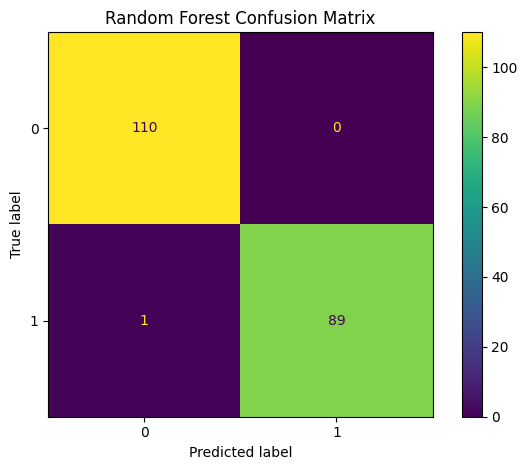


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       110
           1       1.00      0.99      0.99        90

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



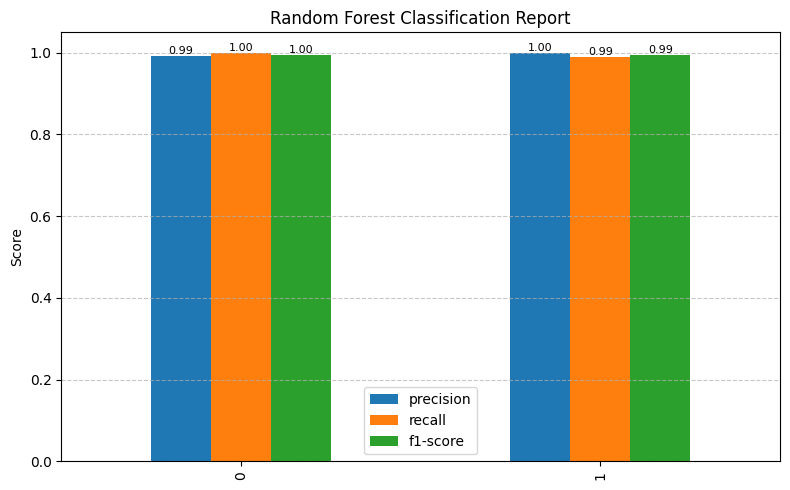



===== Decision Tree Results =====

      Metric   Score
0   Accuracy  0.9950
1  Precision  1.0000
2     Recall  0.9889
3   F1 Score  0.9944

Confusion Matrix:



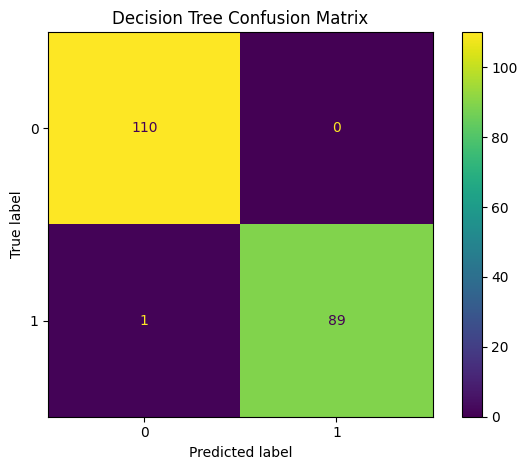


Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       110
           1       1.00      0.99      0.99        90

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



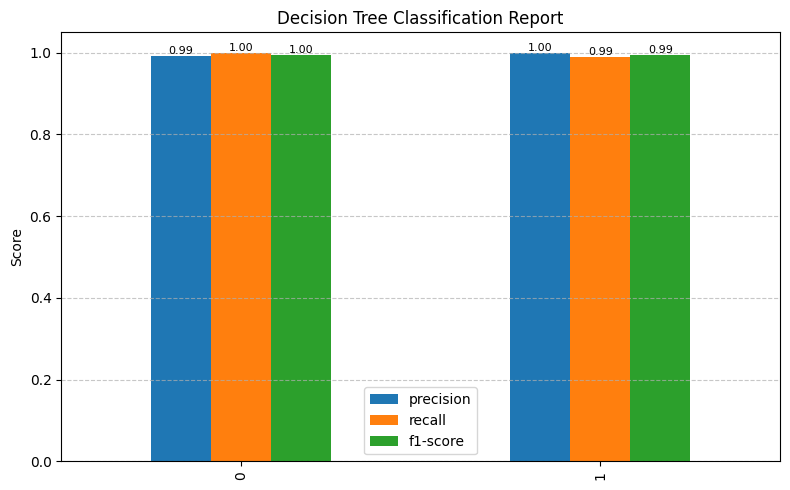

In [13]:
# ============================================================
# RANDOM FOREST RESULTS
# ============================================================

# Calculate confusion matrix for Random Forest
cm_rf_duplicate = confusion_matrix(y_test_duplicate, y_pred_rf_duplicate)

evaluate_model(
    "Random Forest",
    y_test_duplicate,
    y_pred_rf_duplicate,
    cm_rf_duplicate
)

# ============================================================
# DECISION TREE RESULTS
# ============================================================

# Calculate confusion matrix for Decision Tree
cm_dt_duplicate = confusion_matrix(y_test_duplicate, y_pred_dt_duplicate)

evaluate_model(
    "Decision Tree",
    y_test_duplicate,
    y_pred_dt_duplicate,
    cm_dt_duplicate
)

## 9. Duplication Feature Importance
shows which customer similarity features have the greatest influence on predicting whether two records are duplicates.


===== Random Forest Feature Importance =====

                   Feature  Importance
0      raw_name_similarity    0.353708
1  cleaned_name_similarity    0.318251
2                 same_trn    0.206571
3               same_phone    0.111492
4        same_organization    0.009978


/tmp/ipykernel_2282/407618088.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


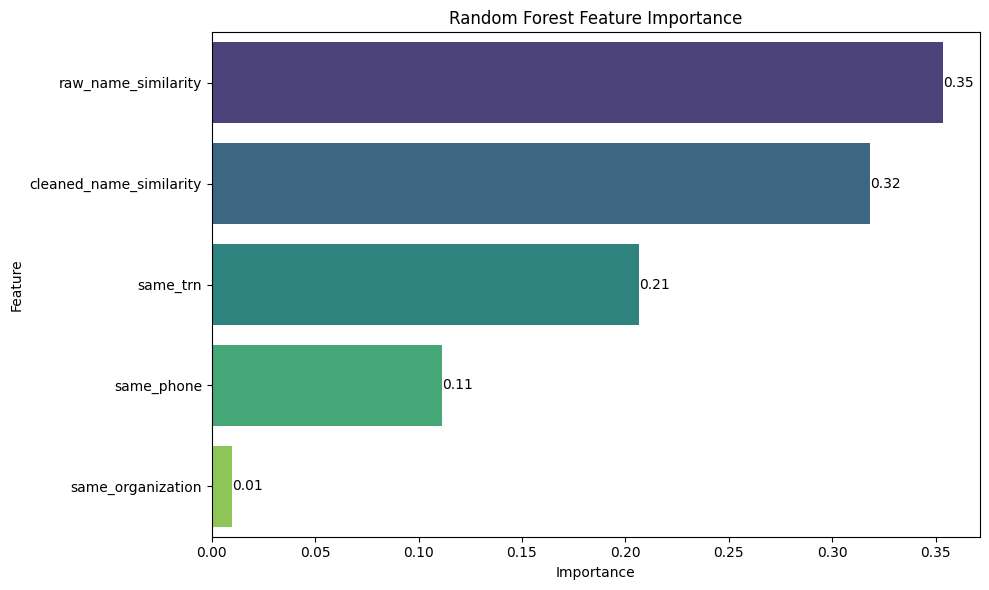

/tmp/ipykernel_2282/407618088.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(



===== Decision Tree Feature Importance =====

                   Feature  Importance
1  cleaned_name_similarity    0.906144
3               same_phone    0.053000
2                 same_trn    0.038445
4        same_organization    0.002008
0      raw_name_similarity    0.000402


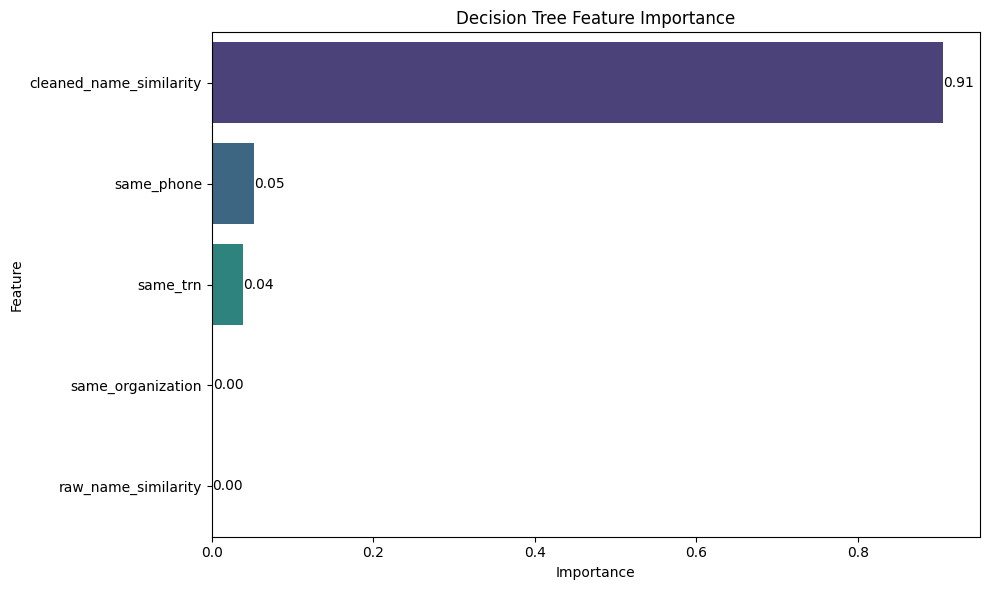

In [14]:
def display_feature_importance(model, feature_names, model_name):
    """Calculates and visualizes feature importance for a given model."""
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(by="Importance", ascending=False)

    print(f"\n===== {model_name} Feature Importance =====\n")
    print(importance_df.head(10))

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x="Importance",
        y="Feature",
        data=importance_df.head(10),
        palette="viridis",
    )

    # Display importance values on bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f"
        )

    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Display Feature Importance for Random Forest
display_feature_importance(rf_model_duplicate, X_duplicate.columns, "Random Forest")

# Display Feature Importance for Decision Tree
display_feature_importance(dt_model_duplicate, X_duplicate.columns, "Decision Tree")

# **Conclusion**
Both the Decision Tree and Random Forest models achieved perfect performance, obtaining accuracy, precision, recall, and F1 scores of 1.00. This is largely attributed to the simplicity of the dataset and the strong predictive power of features such as TRN, phone number, and organization matching. These features enabled the models to clearly distinguish duplicate from non-duplicate records, resulting in no classification errors. However, additional evaluation on more complex datasets would be beneficial to confirm the robustness and generalizability of the models.

# **Part B-Risk Classification**
predicts whether a company should be classified as High Risk or Watchlist based on its financial, operational, and performance indicators.

# 11. Load Risk Classification Dataset

In [ ]:
df_risk = pd.read_csv("/content/person5_risk_classification_dataset.csv")

print('Shape:', df_risk.shape)
display(df_risk.head())


Shape: (108, 39)


,period,company_id,company_name,sector,risk_label,risk_score_0_100,revenue_aed,budget_revenue_aed,cost_of_sales_aed,operating_expenses_aed,gross_profit_aed,ebitda_aed,budget_ebitda_aed,cash_in_aed,cash_out_aed,overdue_receivables_aed,headcount,customer_count,leads_or_orders,conversion_rate_pct,on_time_delivery_pct,customer_satisfaction_score,complaints_count,open_tasks_count,avg_resolution_days,employee_utilization_pct,data_quality_score_pct,profit_margin,gross_margin,expense_ratio,overdue_receivable_ratio,budget_variance_percentage,cash_flow_net_aed,cash_flow_margin,revenue_growth,expense_growth,ebitda_growth,cash_in_growth,cash_out_growth
0,2025-01-01,C001,Lapiz Blue Trading,Trading,Watchlist,57.7,369575,357000,242183,66358,127392,61034,60690,295678,306878,70183,38,29,86,0.3372,0.8196,4.11,0,9,2.3,0.7260,0.9459,0.165146,0.344699,0.834854,0.189902,0.035224,-11200,-0.030305,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025-02-01,C001,Lapiz Blue Trading,Trading,Watchlist,59.0,394948,375735,247920,72821,147028,74207,63875,287675,314115,78310,40,28,92,0.3043,0.8252,3.97,0,27,5.2,0.9356,0.9490,0.187891,0.372272,0.812109,0.198279,0.051132,-26440,-0.066946,0.068655,0.097396,0.215831,-0.027067,0.023583
2,2025-03-01,C001,Lapiz Blue Trading,Trading,High Risk,71.9,362615,390895,218876,62205,143739,81534,66452,277203,279392,65857,37,20,66,0.3030,0.8879,3.56,0,33,7.7,0.9184,0.9176,0.224850,0.396396,0.775150,0.181617,-0.072347,-2189,-0.006037,-0.081866,-0.145782,0.098737,-0.036402,-0.110542
3,2025-04-01,C001,Lapiz Blue Trading,Trading,Watchlist,64.3,438324,399440,297720,77666,140604,62938,67905,346420,365263,89165,40,23,57,0.4035,0.9682,3.57,0,26,8.0,0.7641,0.9533,0.143588,0.320776,0.856412,0.203423,0.097344,-18843,-0.042989,0.208786,0.248549,-0.228077,0.249698,0.307350
4,2025-05-01,C001,Lapiz Blue Trading,Trading,High Risk,70.1,395149,400057,259044,88759,136105,47346,68010,304974,344497,66403,41,25,49,0.5102,0.9484,4.12,0,20,5.1,0.8148,0.9517,0.119818,0.344440,0.880182,0.168045,-0.012268,-39523,-0.100020,-0.098500,0.142830,-0.247736,-0.119641,-0.056852


# **12. Data Checks**

In [ ]:

print("Columns:")
print(df_risk.columns.tolist())

print("\nMissing Values Per Column:")

missing_values = df_risk.isna().sum()

print(
    missing_values[
        missing_values > 0
    ].sort_values(
        ascending=False
    )
)

print("\nRisk Label Distribution:")

print(
    df_risk["risk_label"].value_counts()
)

print("\nDataset Shape:")
print(df_risk.shape)

Columns:
['period', 'company_id', 'company_name', 'sector', 'risk_label', 'risk_score_0_100', 'revenue_aed', 'budget_revenue_aed', 'cost_of_sales_aed', 'operating_expenses_aed', 'gross_profit_aed', 'ebitda_aed', 'budget_ebitda_aed', 'cash_in_aed', 'cash_out_aed', 'overdue_receivables_aed', 'headcount', 'customer_count', 'leads_or_orders', 'conversion_rate_pct', 'on_time_delivery_pct', 'customer_satisfaction_score', 'complaints_count', 'open_tasks_count', 'avg_resolution_days', 'employee_utilization_pct', 'data_quality_score_pct', 'profit_margin', 'gross_margin', 'expense_ratio', 'overdue_receivable_ratio', 'budget_variance_percentage', 'cash_flow_net_aed', 'cash_flow_margin', 'revenue_growth', 'expense_growth', 'ebitda_growth', 'cash_in_growth', 'cash_out_growth']

Missing Values Per Column:
Series([], dtype: int64)

Risk Label Distribution:
risk_label
Watchlist    89
High Risk    19
Name: count, dtype: int64

Dataset Shape:
(108, 39)


# **12. Features and Target**

In [ ]:
# Define the target column
target_risk = 'risk_label'

# Define the feature columns
# Exclude 'risk_score_0_100' to avoid data leakage
feature_cols_risk = [
    'revenue_aed',
    'budget_revenue_aed',
    'cost_of_sales_aed',
    'operating_expenses_aed',
    'gross_profit_aed',
    'ebitda_aed',
    'budget_ebitda_aed',
    'cash_in_aed',
    'cash_out_aed',
    'overdue_receivables_aed',
    'headcount',
    'customer_count',
    'leads_or_orders',
    'conversion_rate_pct',
    'on_time_delivery_pct',
    'customer_satisfaction_score',
    'complaints_count',
    'open_tasks_count',
    'avg_resolution_days',
    'employee_utilization_pct',
    'data_quality_score_pct',
    'profit_margin',
    'gross_margin',
    'expense_ratio',
    'overdue_receivable_ratio',
    'budget_variance_percentage',
    'cash_flow_net_aed',
    'cash_flow_margin',
    'revenue_growth',
    'expense_growth',
    'ebitda_growth',
    'cash_in_growth',
    'cash_out_growth'
]

X_risk = df_risk[feature_cols_risk].copy()
y_risk = df_risk[target_risk].copy()

print("Shape of X_risk:", X_risk.shape)
print("Shape of y_risk:", y_risk.shape)

display(X_risk.head())
display(y_risk.head())

Shape of X_risk: (108, 33)
Shape of y_risk: (108,)


,revenue_aed,budget_revenue_aed,cost_of_sales_aed,operating_expenses_aed,gross_profit_aed,ebitda_aed,budget_ebitda_aed,cash_in_aed,cash_out_aed,overdue_receivables_aed,headcount,customer_count,leads_or_orders,conversion_rate_pct,on_time_delivery_pct,customer_satisfaction_score,complaints_count,open_tasks_count,avg_resolution_days,employee_utilization_pct,data_quality_score_pct,profit_margin,gross_margin,expense_ratio,overdue_receivable_ratio,budget_variance_percentage,cash_flow_net_aed,cash_flow_margin,revenue_growth,expense_growth,ebitda_growth,cash_in_growth,cash_out_growth
0,369575,357000,242183,66358,127392,61034,60690,295678,306878,70183,38,29,86,0.3372,0.8196,4.11,0,9,2.3,0.7260,0.9459,0.165146,0.344699,0.834854,0.189902,0.035224,-11200,-0.030305,0.000000,0.000000,0.000000,0.000000,0.000000
1,394948,375735,247920,72821,147028,74207,63875,287675,314115,78310,40,28,92,0.3043,0.8252,3.97,0,27,5.2,0.9356,0.9490,0.187891,0.372272,0.812109,0.198279,0.051132,-26440,-0.066946,0.068655,0.097396,0.215831,-0.027067,0.023583
2,362615,390895,218876,62205,143739,81534,66452,277203,279392,65857,37,20,66,0.3030,0.8879,3.56,0,33,7.7,0.9184,0.9176,0.224850,0.396396,0.775150,0.181617,-0.072347,-2189,-0.006037,-0.081866,-0.145782,0.098737,-0.036402,-0.110542
3,438324,399440,297720,77666,140604,62938,67905,346420,365263,89165,40,23,57,0.4035,0.9682,3.57,0,26,8.0,0.7641,0.9533,0.143588,0.320776,0.856412,0.203423,0.097344,-18843,-0.042989,0.208786,0.248549,-0.228077,0.249698,0.307350
4,395149,400057,259044,88759,136105,47346,68010,304974,344497,66403,41,25,49,0.5102,0.9484,4.12,0,20,5.1,0.8148,0.9517,0.119818,0.344440,0.880182,0.168045,-0.012268,-39523,-0.100020,-0.098500,0.142830,-0.247736,-0.119641,-0.056852


,risk_label
0,Watchlist
1,Watchlist
2,High Risk
3,Watchlist
4,High Risk


# **13. Split data into train test**

In [ ]:
X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42,
    stratify=y_risk
)

# **14. Scale Data for Logistic Regression Model**

In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_risk_scaled = scaler.fit_transform(X_train_risk)
X_test_risk_scaled = scaler.transform(X_test_risk)

print("X_train_risk_scaled shape:", X_train_risk_scaled.shape)
print("X_test_risk_scaled shape:", X_test_risk_scaled.shape)

X_train_risk_scaled shape: (86, 33)
X_test_risk_scaled shape: (22, 33)


# **15. PCA Dimensional Reduction**
Due to the relatively large number of features in the dataset, PCA dimensionality reduction will be applied to the Logistic Regression model. The performance of the model will then be compared with and without PCA to evaluate its impact on classification accuracy and overall model performance.

In [ ]:
pca = PCA(
    n_components=0.95
)

X_train_pca = pca.fit_transform(
    X_train_risk_scaled
)

X_test_pca = pca.transform(
    X_test_risk_scaled
)

print("Original Features:", X_train_risk.shape[1])
print("PCA Components:", X_train_pca.shape[1])

print(
    f"Explained Variance: "
    f"{sum(pca.explained_variance_ratio_):.4f}"
)

Original Features: 33
PCA Components: 14
Explained Variance: 0.9522


# **16. Train Models**
To identify the most effective approach, 4 classification models were trained and compared: Logistic Regression, Logistic Regression + PCA, Random Forest, and Decision Tree.

In [ ]:
# ============================================================
# LOGISTIC REGRESSION + PCA
# ============================================================
lr_pca_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_pca_model.fit(
    X_train_pca,
    y_train_risk
)

y_pred_lr_pca = lr_pca_model.predict(
    X_test_pca
)

# ============================================================
# LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_risk_scaled, y_train_risk)
y_pred_lr = lr_model.predict(X_test_risk_scaled)

# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_risk, y_train_risk)
y_pred_rf = rf_model.predict(X_test_risk)

# ============================================================
# DECISION TREE
# ============================================================

dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

dt_model.fit(X_train_risk, y_train_risk)
y_pred_dt = dt_model.predict(X_test_risk)

# **17. Evaluate Models**

In [ ]:
def display_model_results(
    model_name,
    y_true,
    y_pred,
    confusion_matrix_result
):

    # ========================================================
    # METRICS RESULTS
    # ========================================================

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    print(f"\n\n===== {model_name} Results =====\n")

    metrics_df = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1
        ]
    })

    print(metrics_df.round(4))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    print("\nConfusion Matrix:\n")

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix_result
    ).plot()

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    report = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    print("\nClassification Report Visualization\n")

    ax = report_df.iloc[:-3][
        ["precision", "recall", "f1-score"]
    ].plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title(
        f"{model_name} Classification Report"
    )

    plt.ylabel("Score")
    plt.ylim(0, 1.05)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=8
        )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.7
    )

    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }



===== Logistic Regression Results =====

      Metric   Score
0   Accuracy  0.8636
1  Precision  0.8533
2     Recall  0.8636
3   F1 Score  0.8557

Confusion Matrix:



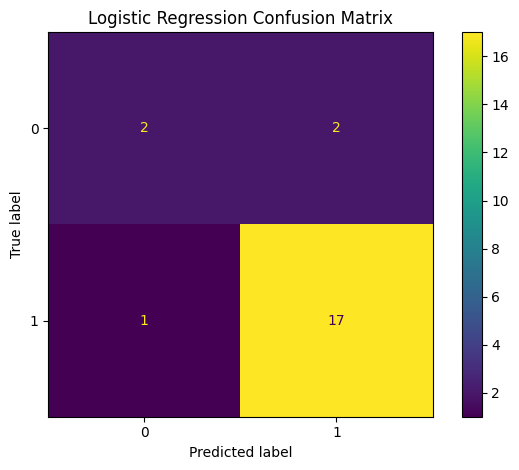


Classification Report:
              precision    recall  f1-score   support

   High Risk       0.67      0.50      0.57         4
   Watchlist       0.89      0.94      0.92        18

    accuracy                           0.86        22
   macro avg       0.78      0.72      0.75        22
weighted avg       0.85      0.86      0.86        22


Classification Report Visualization



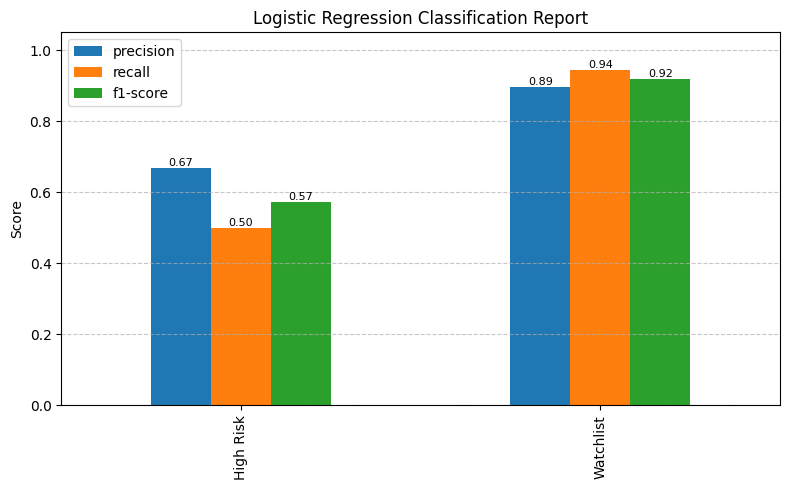



===== Logistic Regression + PCA Results =====

      Metric   Score
0   Accuracy  0.8636
1  Precision  0.8791
2     Recall  0.8636
3   F1 Score  0.8693

Confusion Matrix:



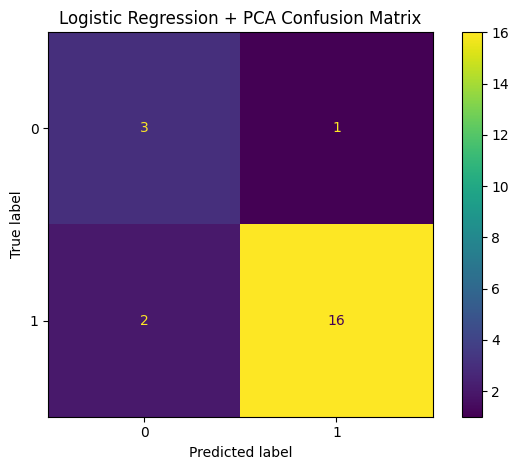


Classification Report:
              precision    recall  f1-score   support

   High Risk       0.60      0.75      0.67         4
   Watchlist       0.94      0.89      0.91        18

    accuracy                           0.86        22
   macro avg       0.77      0.82      0.79        22
weighted avg       0.88      0.86      0.87        22


Classification Report Visualization



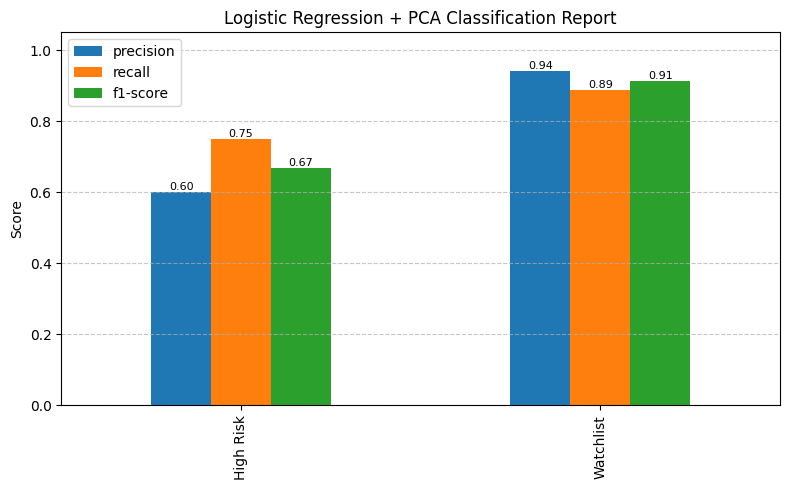



===== Random Forest Results =====

      Metric   Score
0   Accuracy  0.9545
1  Precision  0.9569
2     Recall  0.9545
3   F1 Score  0.9519

Confusion Matrix:



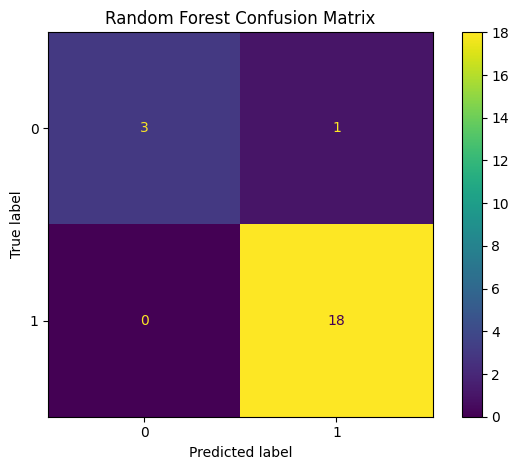


Classification Report:
              precision    recall  f1-score   support

   High Risk       1.00      0.75      0.86         4
   Watchlist       0.95      1.00      0.97        18

    accuracy                           0.95        22
   macro avg       0.97      0.88      0.92        22
weighted avg       0.96      0.95      0.95        22


Classification Report Visualization



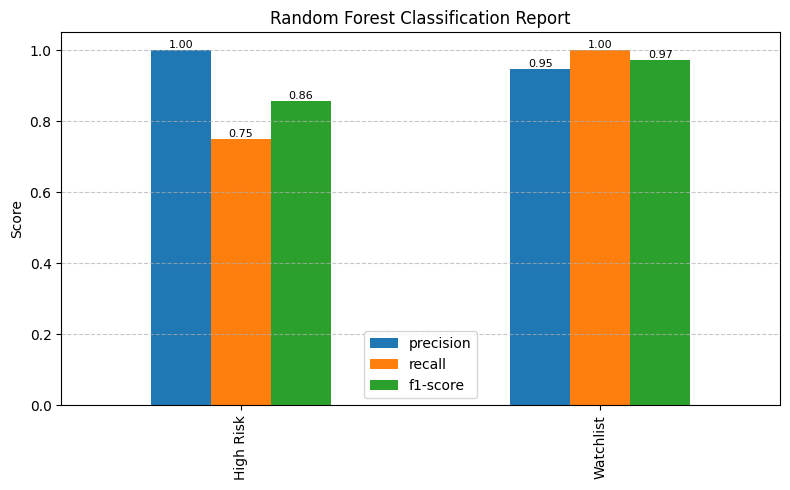



===== Decision Tree Results =====

      Metric   Score
0   Accuracy  0.8636
1  Precision  0.8791
2     Recall  0.8636
3   F1 Score  0.8693

Confusion Matrix:



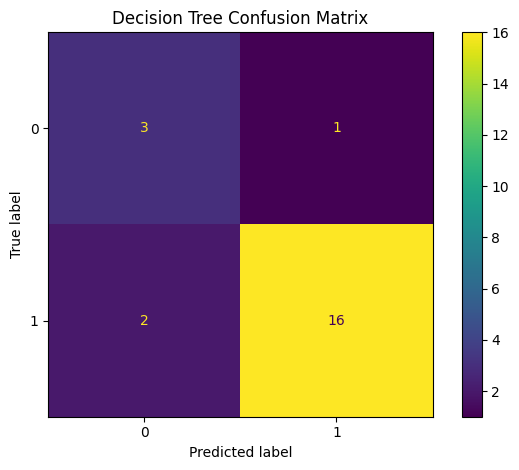


Classification Report:
              precision    recall  f1-score   support

   High Risk       0.60      0.75      0.67         4
   Watchlist       0.94      0.89      0.91        18

    accuracy                           0.86        22
   macro avg       0.77      0.82      0.79        22
weighted avg       0.88      0.86      0.87        22


Classification Report Visualization



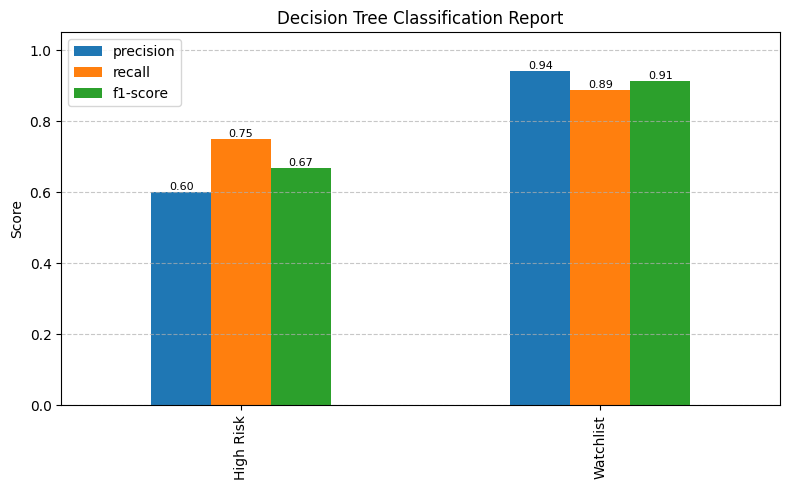


===== RESULTS DATAFRAME =====

                       Model  Accuracy  Precision  Recall  F1 Score
0        Logistic Regression    0.8636     0.8533  0.8636    0.8557
1  Logistic Regression + PCA    0.8636     0.8791  0.8636    0.8693
2              Random Forest    0.9545     0.9569  0.9545    0.9519
3              Decision Tree    0.8636     0.8791  0.8636    0.8693


In [ ]:
# ============================================================
# LOGISTIC REGRESSION RESULTS
# ============================================================

cm_lr = confusion_matrix(
    y_test_risk,
    y_pred_lr
)

lr_results = display_model_results(
    "Logistic Regression",
    y_test_risk,
    y_pred_lr,
    cm_lr
)

# ============================================================
# LOGISTIC REGRESSION + PCA RESULTS
# ============================================================

cm_lr_pca = confusion_matrix(
    y_test_risk,
    y_pred_lr_pca
)

lr_pca_results = display_model_results(
    "Logistic Regression + PCA",
    y_test_risk,
    y_pred_lr_pca,
    cm_lr_pca
)

# ============================================================
# RANDOM FOREST RESULTS
# ============================================================

cm_rf = confusion_matrix(
    y_test_risk,
    y_pred_rf
)

rf_results = display_model_results(
    "Random Forest",
    y_test_risk,
    y_pred_rf,
    cm_rf
)

# ============================================================
# DECISION TREE RESULTS
# ============================================================

cm_dt = confusion_matrix(
    y_test_risk,
    y_pred_dt
)

dt_results = display_model_results(
    "Decision Tree",
    y_test_risk,
    y_pred_dt,
    cm_dt
)


results = pd.DataFrame([
    lr_results,
    lr_pca_results,
    rf_results,
    dt_results
])

print("\n===== RESULTS DATAFRAME =====\n")
print(results.round(4))

# **18. Compare Models**

In [ ]:
def display_model_comparison(results, title):

    # ========================================================
    # MODEL COMPARISON
    # ========================================================

    print("\n\n===== Model Comparison =====\n")

    print(
        results.sort_values(
            by="F1 Score",
            ascending=False
        ).round(4)
    )

    ax = results.plot(
        x="Model",
        y=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],
        kind="bar",
        figsize=(10,6),
        width=0.8
    )

    plt.title(title)
    plt.xlabel("Machine Learning Model")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.7
    )

    plt.legend(
        title="Metric",
        loc="lower right"
    )

    # Display metric values above bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()



===== Model Comparison =====

                       Model  Accuracy  Precision  Recall  F1 Score
2              Random Forest    0.9545     0.9569  0.9545    0.9519
1  Logistic Regression + PCA    0.8636     0.8791  0.8636    0.8693
3              Decision Tree    0.8636     0.8791  0.8636    0.8693
0        Logistic Regression    0.8636     0.8533  0.8636    0.8557


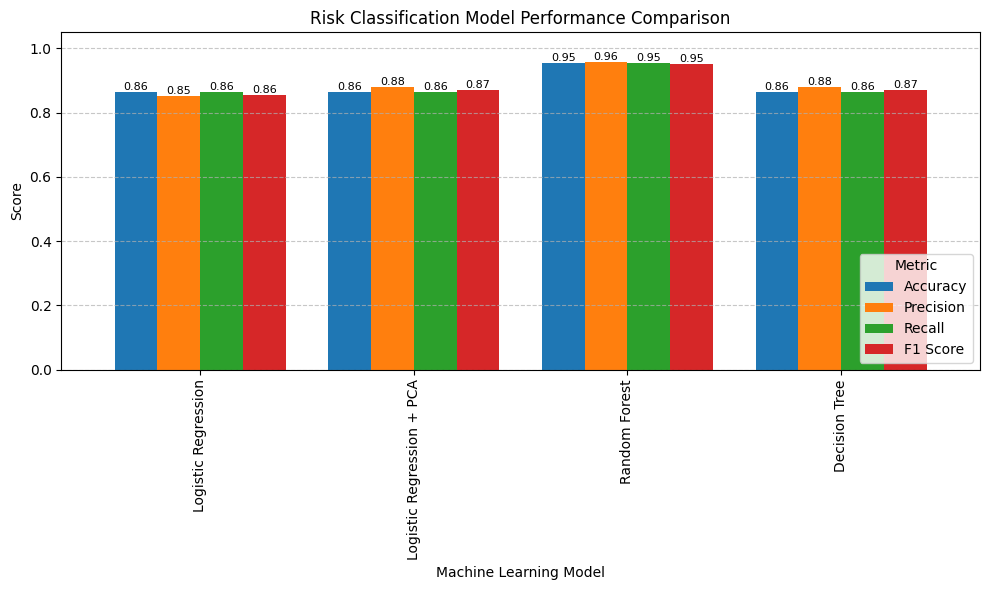

In [ ]:
display_model_comparison(
    results,
    "Risk Classification Model Performance Comparison"
)

# **19. Evaluate Feature Importance**

In [ ]:
def display_logistic_importance(
    model,
    feature_names,
    model_name
):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_[0]
    })

    importance_df["Absolute_Value"] = abs(
        importance_df["Coefficient"]
    )

    importance_df = importance_df.sort_values(
        by="Absolute_Value",
        ascending=False
    )

    print(f"\n===== {model_name} Feature Importance =====\n")
    print(importance_df.head(10))

    ax = importance_df.head(10).plot.barh(
        x="Feature",
        y="Absolute_Value",
        figsize=(8,5)
    )

    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Absolute Coefficient")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f"
        )

    plt.tight_layout()
    plt.show()

    return importance_df

In [ ]:
def display_tree_importance(
    model,
    feature_names,
    model_name
):

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print(f"\n===== {model_name} Feature Importance =====\n")
    print(importance_df.head(10))

    ax = importance_df.head(10).plot.barh(
        x="Feature",
        y="Importance",
        figsize=(8,5)
    )

    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f"
        )

    plt.tight_layout()
    plt.show()

    return importance_df


===== Logistic Regression Feature Importance =====

                        Feature  Coefficient  Absolute_Value
25   budget_variance_percentage     1.268713        1.268713
28               revenue_growth     1.254647        1.254647
24     overdue_receivable_ratio    -1.003055        1.003055
15  customer_satisfaction_score     0.865296        0.865296
32              cash_out_growth     0.797591        0.797591
12              leads_or_orders     0.666687        0.666687
14         on_time_delivery_pct     0.626308        0.626308
9       overdue_receivables_aed    -0.542868        0.542868
10                    headcount    -0.516723        0.516723
17             open_tasks_count    -0.436929        0.436929


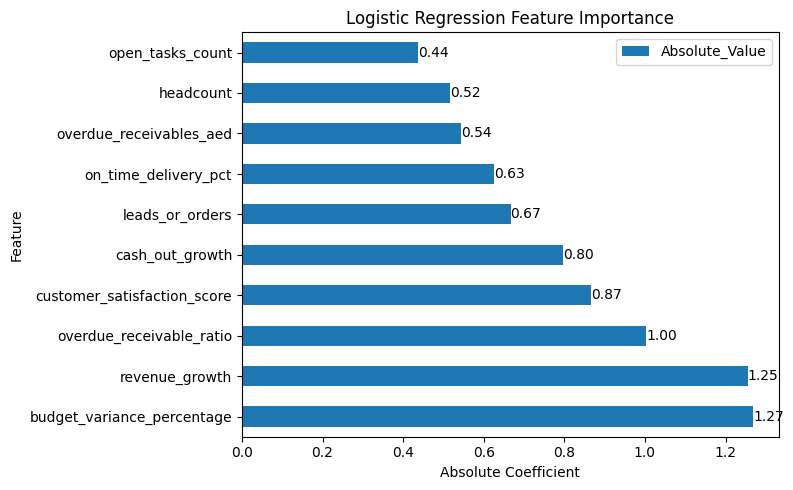


===== Random Forest Feature Importance =====

                        Feature  Importance
28               revenue_growth    0.173241
32              cash_out_growth    0.125112
25   budget_variance_percentage    0.099908
29               expense_growth    0.069645
24     overdue_receivable_ratio    0.067111
14         on_time_delivery_pct    0.044802
31               cash_in_growth    0.034702
19     employee_utilization_pct    0.031779
9       overdue_receivables_aed    0.031227
15  customer_satisfaction_score    0.021885


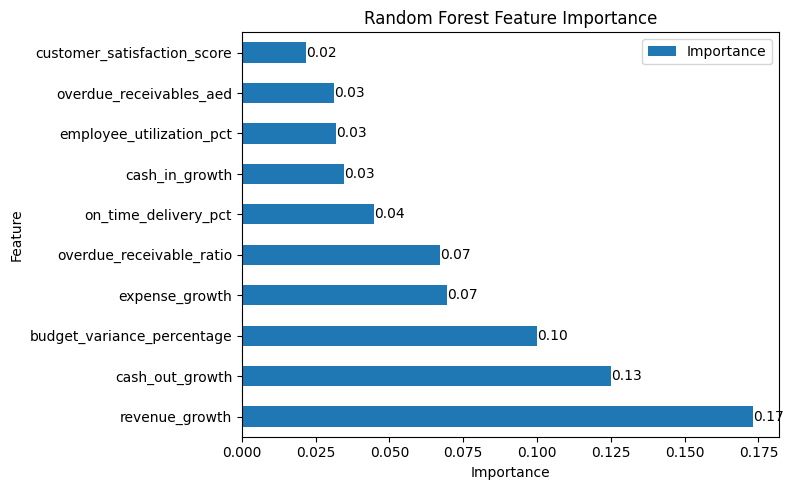


===== Decision Tree Feature Importance =====

                     Feature  Importance
28            revenue_growth    0.525875
24  overdue_receivable_ratio    0.171308
31            cash_in_growth    0.167714
7                cash_in_aed    0.074540
14      on_time_delivery_pct    0.060563
0                revenue_aed    0.000000
4           gross_profit_aed    0.000000
3     operating_expenses_aed    0.000000
1         budget_revenue_aed    0.000000
8               cash_out_aed    0.000000


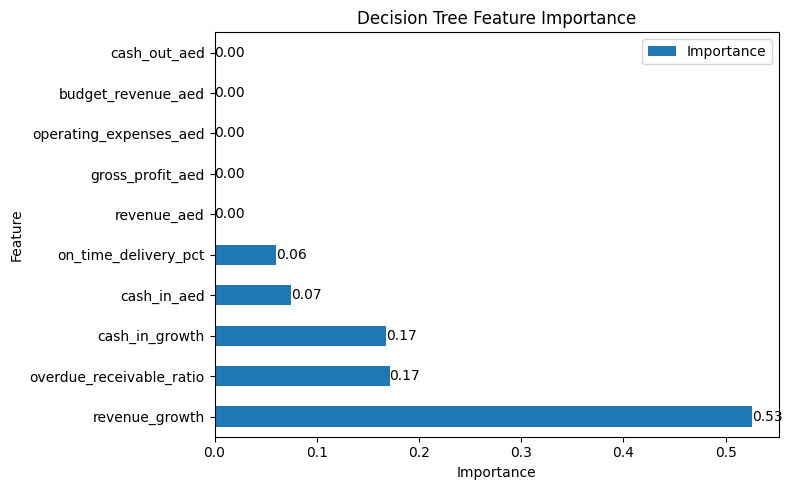

In [ ]:

# ============================================================
# LOGISTIC REGRESSION FEATURE IMPORTANCE
# ============================================================

lr_importance = display_logistic_importance(
    lr_model,
    X_risk.columns,
    "Logistic Regression"
)

# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = display_tree_importance(
    rf_model,
    X_risk.columns,
    "Random Forest"
)

# ============================================================
# DECISION TREE FEATURE IMPORTANCE
# ============================================================

dt_importance = display_tree_importance(
    dt_model,
    X_risk.columns,
    "Decision Tree"
)

# **20. Final Model Summary**

In [ ]:
# ============================================================
# BEST MODEL SELECTION
# ============================================================

best_model_row = results.loc[
    results["F1 Score"].idxmax()
]

print("\n===== BEST MODEL SELECTION =====\n")

summary_df = pd.DataFrame(
    best_model_row
).transpose()

print(summary_df.round(4))

print(
    f"\nBased on model evaluation results, "
    f"{best_model_row['Model']} achieved the highest "
    f"F1 Score ({best_model_row['F1 Score']:.4f}) "
    f"and was selected as the final Risk Classification model."
)


===== BEST MODEL SELECTION =====

           Model  Accuracy Precision    Recall  F1 Score
2  Random Forest  0.954545  0.956938  0.954545  0.951913

Based on model evaluation results, Random Forest achieved the highest F1 Score (0.9519) and was selected as the final Risk Classification model.


# **Conclusion**
Based on the evaluation results, Random Forest was identified as the best-performing model, achieving the highest F1 Score of 0.95. While Logistic Regression, Logistic Regression with PCA, and Decision Tree produced satisfactory results, Random Forest consistently outperformed the other models across all evaluation metrics. The PCA experiment demonstrated that dimensionality reduction could be applied successfully; however, it did not improve performance beyond the Random Forest model. Consequently, Random Forest was selected as the final risk classification model due to its superior accuracy, robustness, and ability to capture complex relationships within the financial and operational data.